# Práctico 1: EDA y Visualización

Esta notebook traduce las consignas de `practico/practico_1.md` a un flujo de trabajo ejecutable y ordenado.

## Objetivo
Explorar los datos de adopción de IA para: 
1. Entender su estructura y calidad.
2. Describir variables clave de manera univariada.
3. Analizar relaciones bivariadas relevantes para el proyecto.
4. Formular hipóesis de investigación para los próximos prácticos.

## 1) Importación de librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 2) Carga de datos

Esta celda carga los tres archivos provistos en `data/raw/`:
- `ai_company_adoption.csv`
- `ai_industry_summary.csv`
- `country_ai_index.csv`

Usamos rutas relativas desde la carpeta `notebook/` para facilitar portabilidad del proyecto.
Finalmente, mostramos las dimensiones iniciales para validar que la lectura fue correcta.

In [2]:
company = pd.read_csv('../data/raw/ai_company_adoption.csv')
industry = pd.read_csv('../data/raw/ai_industry_summary.csv')
country = pd.read_csv('../data/raw/country_ai_index.csv')

print('company:', company.shape)
print('industry:', industry.shape)
print('country:', country.shape)

company: (150025, 43)
industry: (9, 8)
country: (30, 8)


In [3]:
# Chequear datos duplicados


In [4]:
company.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150025 entries, 0 to 150024
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   response_id                  150025 non-null  int64  
 1   company_id                   150025 non-null  object 
 2   survey_year                  150024 non-null  float64
 3   quarter                      150025 non-null  object 
 4   country                      150024 non-null  object 
 5   region                       150024 non-null  object 
 6   industry                     147772 non-null  object 
 7   company_size                 147774 non-null  object 
 8   num_employees                150025 non-null  float64
 9   annual_revenue_usd_millions  147778 non-null  float64
 10  company_founding_year        150025 non-null  float64
 11  company_age                  150025 non-null  float64
 12  company_age_group            150024 non-null  object 
 13 

### Interpretación tentativa de las columnas de `company`

Las siguientes descripciones son la mejor interpretación posible a partir de los nombres de las variables y de los resultados observados en la notebook. Como no se dispone de un diccionario de datos, generamos suposiciones educadas acerca del contenido de cada variable.

| Columna | Contenido probable |
|---|---|
| `response_id` | Identificador único de cada respuesta o registro de la encuesta. |
| `company_id` | Identificador de la empresa; puede repetirse si una misma compañía fue observada en distintos períodos. Para muchas empresas, existen hasta 16 observaciones: una por cada Q del año, durante cuatro años |
| `survey_year` | Año calendario en que se realizó la observación o encuesta. |
| `quarter` | Trimestre del año correspondiente a la observación, por ejemplo, Q1 a Q4. |
| `country` | País en el que se ubica o se registra la empresa encuestada. |
| `region` | Región geográfica más amplia a la que pertenece el país. |
| `industry` | Sector o industria principal en que opera la empresa. |
| `company_size` | Categoría de tamaño de la empresa, como startup, pyme o gran empresa. |
| `num_employees` | Cantidad de personas empleadas por la compañía. |
| `annual_revenue_usd_millions` | Facturación o ingresos anuales de la empresa, expresados en millones de dólares estadounidenses. |
| `company_founding_year` | Año de fundación de la empresa. |
| `company_age` | Antigüedad de la empresa en años al momento de la observación. |
| `company_age_group` | Rango categórico de antigüedad de la empresa. |
| `ai_adoption_rate` | Porcentaje o índice que estima el grado de adopción de IA en la empresa. Aunque parece expresado como porcentaje, se observan valores fuera del rango 0–100 que requieren validación. |
| `ai_adoption_stage` | Etapa de adopción de IA: sin adopción, piloto, adopción parcial o adopción completa. |
| `years_using_ai` | Cantidad de años que la empresa lleva utilizando tecnologías de IA. |
| `ai_primary_tool` | Herramienta o plataforma de IA utilizada principalmente por la empresa. |
| `num_ai_tools_used` | Número de herramientas de IA distintas que utiliza la empresa. |
| `ai_use_case` | Principal caso de uso o área funcional en la que se aplica IA. |
| `ai_projects_active` | Cantidad de proyectos de IA actualmente activos. |
| `ai_training_hours` | Horas dedicadas a capacitación en IA; la población o período de referencia no están especificados. |
| `ai_budget_percentage` | Porcentaje del presupuesto de la empresa asignado a iniciativas de IA. |
| `ai_maturity_score` | Puntaje sintético de madurez de la empresa en el uso de IA; por los resultados parece estar normalizado entre 0 y 1. |
| `ai_failure_rate` | Porcentaje estimado de proyectos o iniciativas de IA que no alcanzaron sus objetivos. |
| `ai_investment_per_employee` | Inversión monetaria en IA por empleado, probablemente expresada en dólares estadounidenses. |
| `regulatory_compliance_score` | Puntaje que refleja el nivel de cumplimiento de normas y regulaciones vinculadas con IA. |
| `data_privacy_level` | Nivel categórico de protección o madurez en privacidad de datos. |
| `ai_ethics_committee` | Indica si la empresa cuenta con un comité de ética para temas de IA. |
| `ai_risk_management_score` | Puntaje de capacidad o madurez para gestionar riesgos asociados con la IA. |
| `remote_work_percentage` | Porcentaje de trabajo o de empleados bajo modalidad remota. |
| `employee_satisfaction_score` | Puntaje de satisfacción de los empleados. |
| `task_automation_rate` | Porcentaje de tareas automatizadas, probablemente mediante IA. |
| `time_saved_per_week` | Horas de trabajo ahorradas por semana gracias a la IA; la unidad de análisis exacta no está especificada. |
| `productivity_change_percent` | Variación porcentual de la productividad, presumiblemente después de adoptar IA. Puede ser negativa si la productividad disminuyó. |
| `jobs_displaced` | Cantidad de puestos de trabajo desplazados o eliminados atribuibles a la adopción de IA. |
| `jobs_created` | Cantidad de nuevos puestos de trabajo creados en relación con la adopción de IA. |
| `reskilled_employees` | Cantidad de empleados recapacitados o reconvertidos para desempeñar nuevas funciones. |
| `revenue_growth_percent` | Crecimiento porcentual de los ingresos, posiblemente asociado con el uso de IA. |
| `cost_reduction_percent` | Reducción porcentual de costos, posiblemente atribuida a la adopción de IA. |
| `innovation_score` | Puntaje que resume el nivel o la capacidad de innovación de la empresa. |
| `customer_satisfaction` | Puntaje de satisfacción de los clientes. |
| `survey_source` | Fuente, estudio o institución de la que proviene la información. |
| `data_collection_method` | Método utilizado para recolectar los datos, como entrevista, encuesta o recopilación mediante API. |

In [24]:
# Check company_id duplicates and order by most repeated id
company['ai_primary_tool'].value_counts()

ai_primary_tool
ChatGPT               45394
Claude                24196
Custom Internal AI    23958
Gemini                23655
GitHub Copilot        20069
Other                 10501
Name: count, dtype: int64

In [6]:
industry.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   industry                         9 non-null      str    
 1   avg_ai_adoption_rate             9 non-null      float64
 2   avg_productivity_change_percent  9 non-null      float64
 3   avg_ai_maturity_score            9 non-null      float64
 4   avg_ai_failure_rate              9 non-null      float64
 5   avg_jobs_displaced               9 non-null      float64
 6   avg_jobs_created                 9 non-null      float64
 7   avg_customer_satisfaction        9 non-null      float64
dtypes: float64(7), str(1)
memory usage: 708.0 bytes


In [7]:
country.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   country                     30 non-null     str    
 1   region                      30 non-null     str    
 2   gdp_per_capita              30 non-null     float64
 3   internet_penetration        30 non-null     float64
 4   digital_maturity_index      30 non-null     float64
 5   country_ai_policy           30 non-null     str    
 6   ai_patent_filings_2024      30 non-null     int64  
 7   ai_researchers_per_million  30 non-null     float64
dtypes: float64(4), int64(1), str(3)
memory usage: 2.0 KB


En base al análisis rápido realizado, podemos concluir que las bases están compuestas de la siguiente manera:
`company`: microdatos a nivel empresa/respuesta (archivo principal del análisis).
`industry`: resumen agregado por industria (útil para contraste).
`country`: contexto país (madurez digital, I+D, políticas, etc.).


## 3) Descripción general del dataset

### ¿Cuántos registros y variables tiene cada archivo?
La celda siguiente construye una tabla-resumen con filas (registros), columnas (variables) y cantidad de variables numéricas/categóricas por dataset.

### ¿Qué tipo de variables hay?
Distinguimos tipos en dos grupos prácticos:
- Numéricas (`number`): continuas o discretas para métricas/cantidades.
- Categóricas (`object`, `category`): etiquetas de país, industria, etapa de adopción, etc.

Esto permite entender qué tipo de análisis y gráficos corresponde aplicar después.

In [3]:
summary = pd.DataFrame({
    'dataset': ['company', 'industry', 'country'],
    'rows': [len(company), len(industry), len(country)],
    'columns': [company.shape[1], industry.shape[1], country.shape[1]],
    'numeric_vars': [company.select_dtypes(include='number').shape[1], industry.select_dtypes(include='number').shape[1], country.select_dtypes(include='number').shape[1]],
    'categorical_vars': [company.select_dtypes(exclude='number').shape[1], industry.select_dtypes(exclude='number').shape[1], country.select_dtypes(exclude='number').shape[1]],
})
summary

,dataset,rows,columns,numeric_vars,categorical_vars
0,company,150025,43,29,14
1,industry,9,8,7,1
2,country,30,8,5,3


### ¿Qué representa cada archivo y cómo se relacionan entre sí?

La celda siguiente verifica claves y relaciones lógicas:
- `company` se puede agregar por `industry` para comparar contra la tabla `industry`.
- `company` se puede agregar por `country` para conectar con la tabla `country`.

In [4]:
print('Industrias en company:', company['industry'].nunique())
print('Industrias en industry:', industry['industry'].nunique())
print('Paises en company:', company['country'].nunique())
print('Paises en country:', country['country'].nunique())

print('Industrias de industry que faltan en company:', set(industry['industry']) - set(company['industry'].dropna()))
print('Paises de country que faltan en company:', set(country['country']) - set(company['country'].dropna()))

Industrias en company: 9
Industrias en industry: 9
Paises en company: 30
Paises en country: 30
Industrias de industry que faltan en company: set()
Paises de country que faltan en company: set()


Estas parecen buenas noticias! Todas las observaciones que están en las tablas agregadas también se encuentra en la tabla de compañías.

## 4) Análisis univariado (5 variables relevantes)

A continuación analizamos al menos cinco variables del archivo principal `company`:
1. `ai_adoption_rate` (numérica)
2. `ai_maturity_score` (numérica)
3. `productivity_change_percent` (numérica)
4. `industry` (categórica)
5. `company_size` (categórica)

Para las numéricas mostramos **histograma + boxplot** (forma, dispersión, asimetría y outliers).
Para categóricas mostramos **frecuencias relativas** (composición).

Además de los gráficos, cada celda imprime estadíisticas básicas para respaldar la interpretación.


ai_adoption_rate
count    147776.000000
mean         36.431407
std          15.418903
min        -137.995275
25%          26.420000
50%          36.330000
75%          46.230000
max         210.119890
Name: ai_adoption_rate, dtype: float64


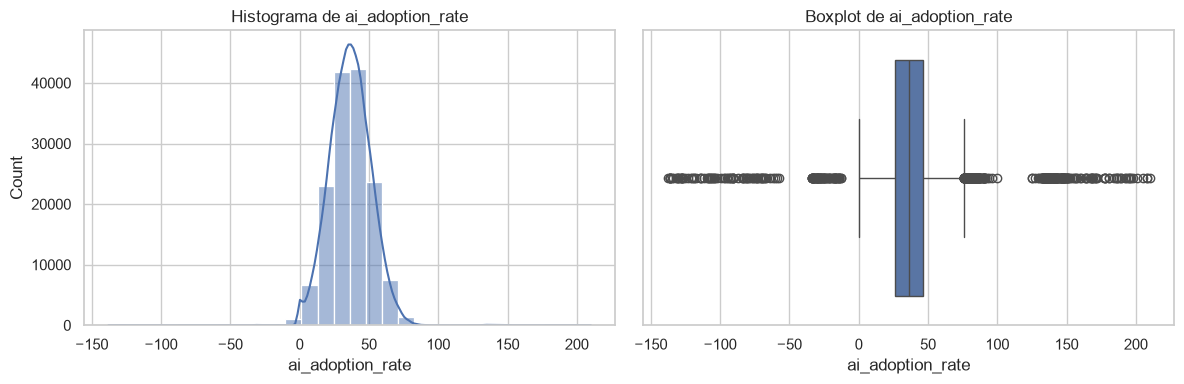


ai_maturity_score
count    150025.000000
mean          0.344678
std           0.133817
min           0.000000
25%           0.250000
50%           0.341000
75%           0.435000
max           0.904000
Name: ai_maturity_score, dtype: float64


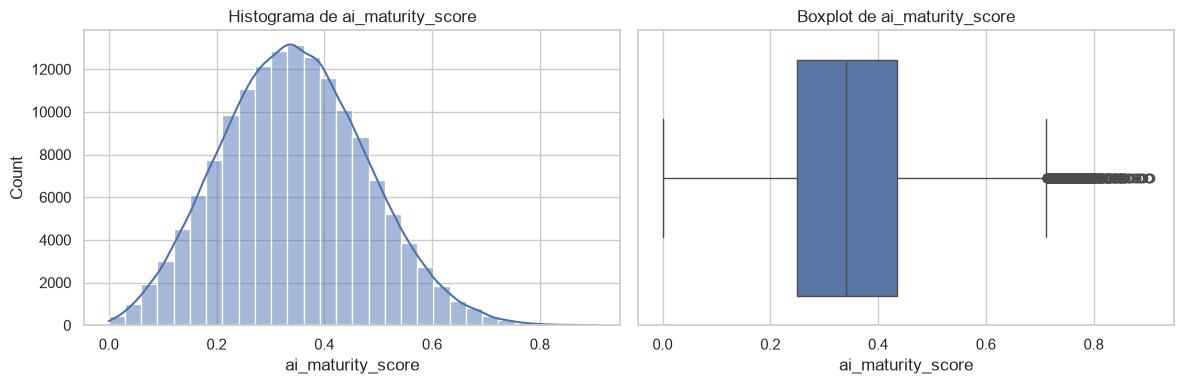


productivity_change_percent
count    150025.000000
mean          9.310881
std           6.368602
min         -57.053637
25%           5.060000
50%           9.060000
75%          13.130000
max         119.200258
Name: productivity_change_percent, dtype: float64


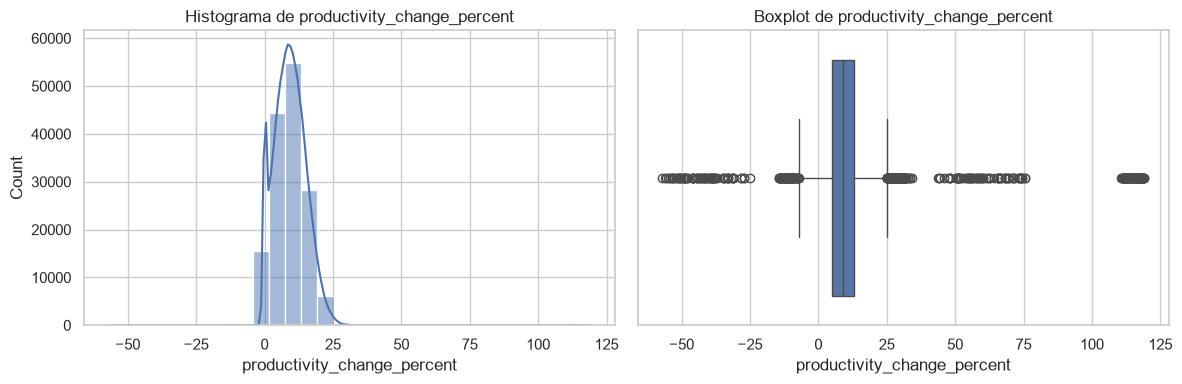

In [8]:
num_vars = ['ai_adoption_rate', 'ai_maturity_score', 'productivity_change_percent']

for col in num_vars:
    print(f'\n{col}')
    print(company[col].describe())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(company[col], bins=30, kde=True, ax=axes[0])
    axes[0].set_title(f'Histograma de {col}')

    sns.boxplot(x=company[col], ax=axes[1])
    axes[1].set_title(f'Boxplot de {col}')

    plt.tight_layout()
    plt.show()

Analizar productivy_change_opercent por aiadoption_stage



Hay algo raro con la métrica `ai_adoption_rate`: existen tasas superiores al 100% y también inferiores al 0%. Lo mejor sería limpiar esa variable de valores atípicos.

Con respecto al `ai_maturity_score`, parece ser una métrica que va entre 0 y 1. Tiene una distribución normal con una ligera asimetría hacia la derecha. 

El `productivity_change_percent` también muestra valores negativos y mayores al 100%. Sin embargo, esto podría explicarse por una disminución, o un aumento superior al 100% (más del doble) de la productividad luego de la adopción de IA.

Luego de esta examinación, podemos excluir los valores atípicos de la métrica `ai_adoption_rate`. 

In [25]:
# Filter anomalous values in ai_adoption_rate
company = company[(company['ai_adoption_rate'] >= 0) & (company['ai_adoption_rate'] <= 100)]

La siguiente celda cubre dos variables categóricas con mayor impacto interpretativo:

- `industry`: permite identificar sectores más representados y contextualizar comparaciones.
- `company_size`: muestra composición por tamaño empresarial, importante porque puede sesgar niveles de inversión/adopción.

Usamos frecuencias normalizadas (`value_counts(normalize=True)`) para que la lectura sea porcentual y comparable.


Distribucion relativa de industry (top 10):
industry
Technology       13.85
Finance          13.26
Healthcare       12.21
Manufacturing    11.53
Retail           10.77
Agriculture      10.21
Education         9.98
Logistics         8.51
Consulting        8.19
NaN               1.50
Name: proportion, dtype: float64


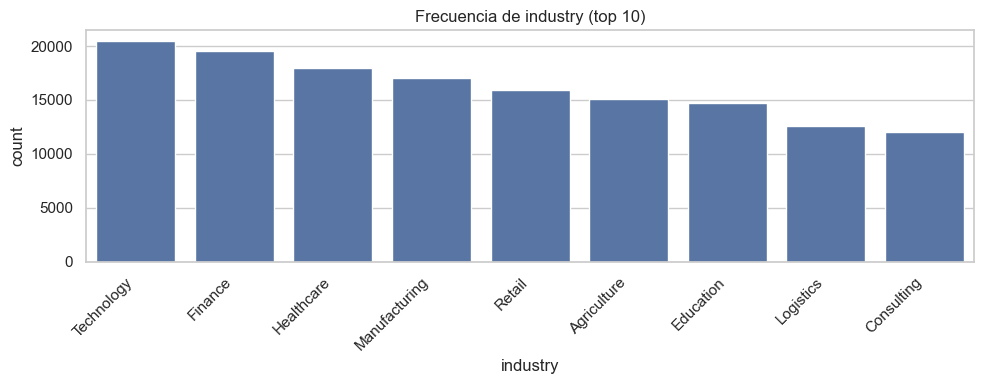


Distribucion relativa de company_size (top 10):
company_size
SME           41.95
Startup       37.24
Enterprise    19.30
NaN            1.51
Name: proportion, dtype: float64


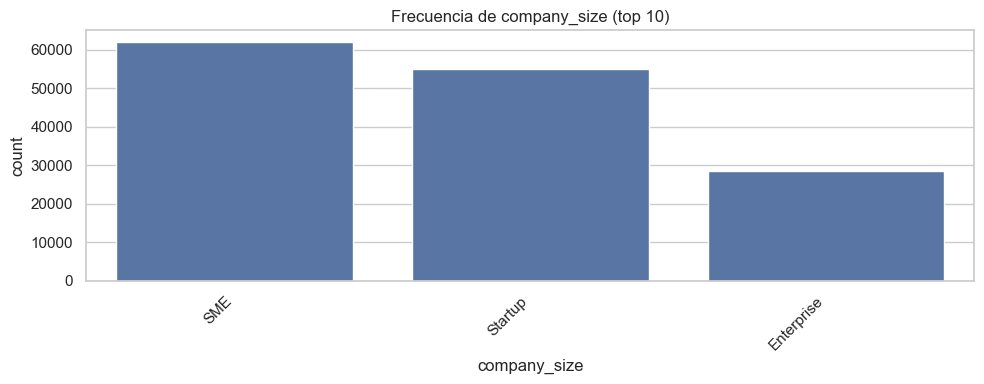

In [26]:
for col in ['industry', 'company_size']:
    dist = company[col].value_counts(dropna=False, normalize=True).head(10)
    print(f'\nDistribucion relativa de {col} (top 10):')
    print((dist * 100).round(2))

    plt.figure(figsize=(10, 4))
    sns.countplot(data=company, x=col, order=company[col].value_counts().index[:10])
    plt.title(f'Frecuencia de {col} (top 10)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

Tenemos un porcentaje pequeño de valores nulos en `industry` y `company_size`, que podrían ser imputados o eliminados según el análisis posterior. Por otro lado, la industria mejor representada es `Technology`, con un 13.85% de las observaciones, mientras que la categoría de tamaño más frecuente es `SME` (empresas pequeñas), con un 41.95% de los registros.

## 5) Análisis bivariado y comparaciones (3 relaciones)

Aquí exploramos tres relaciones alineadas con la consigna:

1. **Adopción de IA por industria**
   - Pregunta: qué sectores muestran mayor/menor tasa de adopción?
   - Gráfico: boxplot por industria para observar nivel típico y variabilidad.

2. **Inversión en IA vs cambio de productividad**
   - Pregunta: mayor inversión por empleado se asocia con mayor productividad?
   - Gráfico: dispersión con tendencia lineal (`regplot`).

3. **Diferencias entre regiones y vínculo país-madurez digital**
   - Preguntas: hay brechas de adopción por región? la madurez digital del país se relaciona con adopción promedio?
   - Gráficos: barplot por región + dispersión entre `digital_maturity_index` y adopción promedio por país.

### Adopción de IA por industria

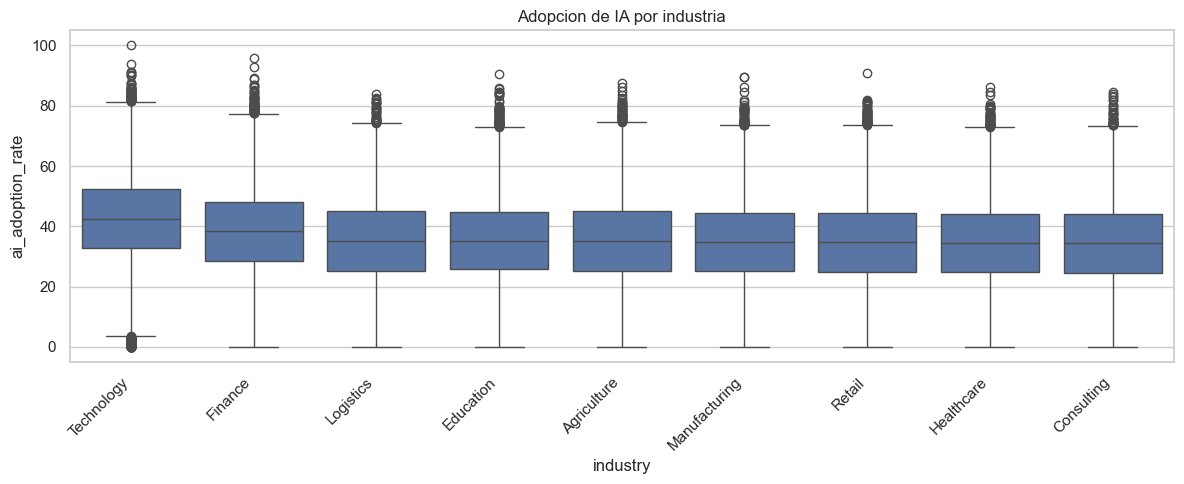

industry
Technology       42.49
Finance          38.34
Logistics        35.26
Education        35.26
Agriculture      35.22
Manufacturing    34.74
Retail           34.73
Healthcare       34.61
Consulting       34.53
Name: ai_adoption_rate, dtype: float64

In [27]:
order_industry = company.groupby('industry')['ai_adoption_rate'].mean().sort_values(ascending=False).index

plt.figure(figsize=(12, 5))
sns.boxplot(data=company, x='industry', y='ai_adoption_rate', order=order_industry)
plt.title('Adopcion de IA por industria')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

company.groupby('industry')['ai_adoption_rate'].mean().sort_values(ascending=False).round(2).head(10)

Aunque tecnología y finanzas aparecen con tasas levemente superiores, no parece haber diferencias significativas entre las industrias respecto de su tasa de adopción media. Sin embargo, es importante ponderar que cada compañía puede tener varias observaciones a lo largo del tiempo, y las empresas con más observaciones pesan más. Por lo tanto, comparamos en el último trimestre común.

C:\Users\erics\AppData\Local\Temp\ipykernel_5528\2735300569.py:6: FutureWarning: Constructing PeriodIndex from fields is deprecated. Use PeriodIndex.from_fields instead.
  industry_df['period'] = pd.PeriodIndex(


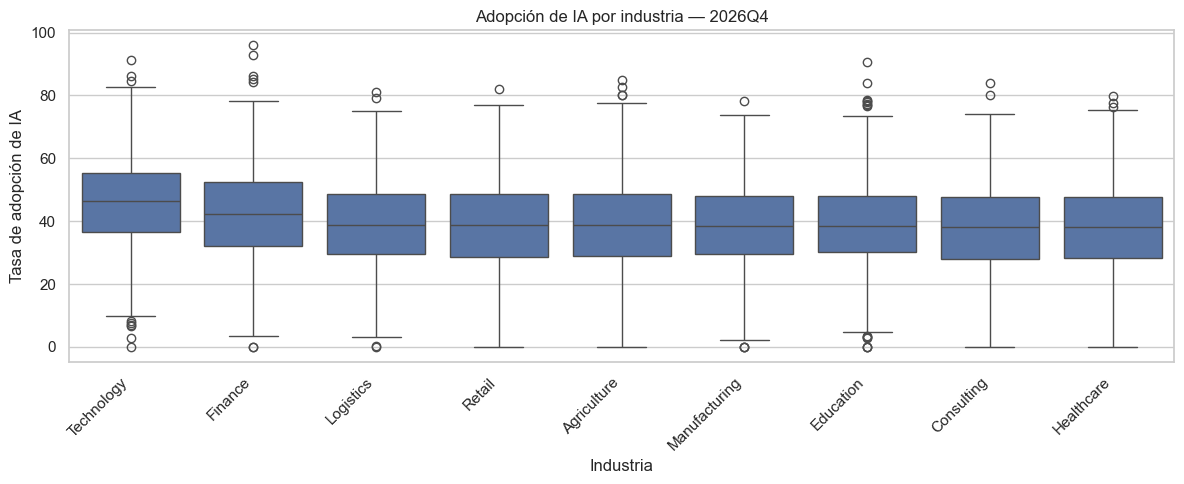

industry
Technology       45.92
Finance          42.38
Education        39.10
Agriculture      38.95
Logistics        38.77
Manufacturing    38.68
Retail           38.65
Healthcare       38.09
Consulting       37.73
Name: ai_adoption_rate, dtype: float64

In [30]:
industry_df = company.dropna(
    subset=['company_id', 'survey_year', 'quarter',
            'industry', 'ai_adoption_rate']
).copy()

industry_df['period'] = pd.PeriodIndex(
    year=industry_df['survey_year'].astype(int),
    quarter=industry_df['quarter'].str.extract(r'(\d)')[0].astype(int),
    freq='Q'
)

latest_period = industry_df['period'].max()

industry_latest = industry_df[
    industry_df['period'].eq(latest_period)
].copy()

industry_order = (
    industry_latest
    .groupby('industry')['ai_adoption_rate']
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(12, 5))
sns.boxplot(
    data=industry_latest,
    x='industry',
    y='ai_adoption_rate',
    order=industry_order
)

plt.title(f'Adopción de IA por industria — {latest_period}')
plt.xlabel('Industria')
plt.ylabel('Tasa de adopción de IA')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

industry_latest.groupby('industry')['ai_adoption_rate'].mean().sort_values(ascending=False).round(2).head(10)

Bien, el nivel de adopción de IA por industria del último trimestre común muestra un patrón muy similar al de la adopción promedio a lo largo de todo el período. Esto sugiere que las diferencias entre industrias son consistentes y no se deben a variaciones temporales. El sector tecnológico sigue liderando, algo que se mantiene a lo largo del tiempo y que podría reflejar una mayor inversión en innovación y adopción de tecnologías emergentes en este sector, algo que es esperable. 

Nos preguntamos si la evolución de la adopción de IA a lo largo del tiempo es consistente entre industrias, o si algunas industrias muestran un crecimiento más rápido que otras. Para esto, podemos analizar la tendencia temporal de la adopción de IA por industria y observar si hay diferencias significativas en las tasas de crecimiento.

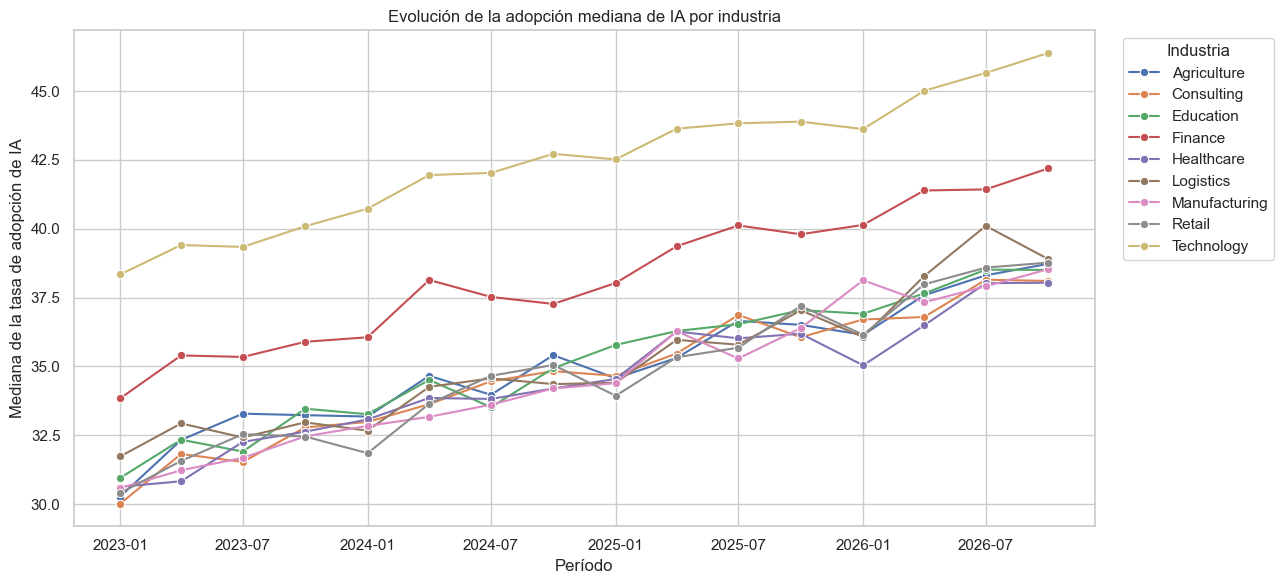

In [31]:
industry_evolution = (
    industry_df
    .groupby(['period', 'industry'])['ai_adoption_rate']
    .agg(
        median='median',
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        companies='count'
    )
    .reset_index()
)

industry_evolution['date'] = (
    industry_evolution['period'].dt.to_timestamp()
)

plt.figure(figsize=(13, 6))

sns.lineplot(
    data=industry_evolution,
    x='date',
    y='median',
    hue='industry',
    marker='o'
)

plt.title('Evolución de la adopción mediana de IA por industria')
plt.xlabel('Período')
plt.ylabel('Mediana de la tasa de adopción de IA')
plt.legend(title='Industria', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Todas las industrias muestran un ritmo de crecimiento similar en la adopción de IA a lo largo del tiempo. Sin embargo, los sectores tecnológico y financiero llevan siempre una ventaja en la adopción de IA, lo que podría reflejar una mayor inversión en innovación y adopción de tecnologías emergentes en estos sectores.

### Inversión en IA por empleado vs cambio de productividad

En primer lugar, observamos si a nivel global existe una relación entre la inversión en IA por empleado y el cambio de productividad.l

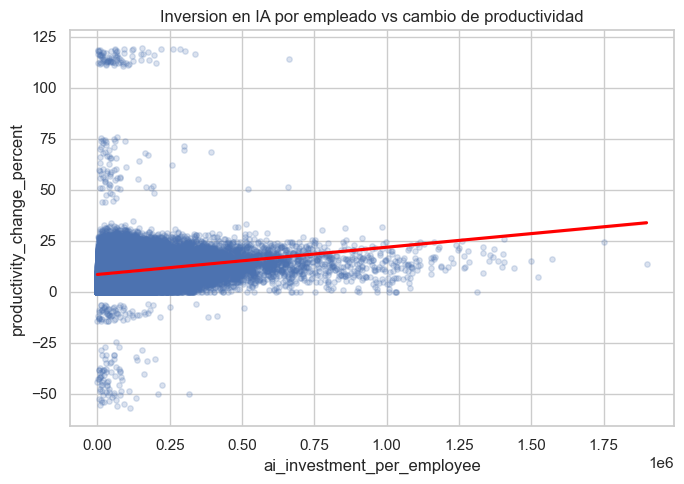

,ai_investment_per_employee,productivity_change_percent
ai_investment_per_employee,1.000,0.187
productivity_change_percent,0.187,1.000


In [20]:
# Limpiamos las variables de valores negativos y nulos para el análisis de correlación
company_clean = company[(company['ai_investment_per_employee'] >= 0)].dropna(subset=['productivity_change_percent', 'ai_investment_per_employee'])
plt.figure(figsize=(7, 5))
sns.regplot(data=company_clean, x='ai_investment_per_employee', y='productivity_change_percent', scatter_kws={'alpha': 0.2, 's': 15}, line_kws={'color': 'red'})
plt.title('Inversion en IA por empleado vs cambio de productividad')
plt.tight_layout()
plt.show()

company_clean[['ai_investment_per_employee', 'productivity_change_percent']].corr().round(3)

Revisamos la relación entre las variables en el último trimestre común, para evitar sesgos por empresas con múltiples observaciones. 

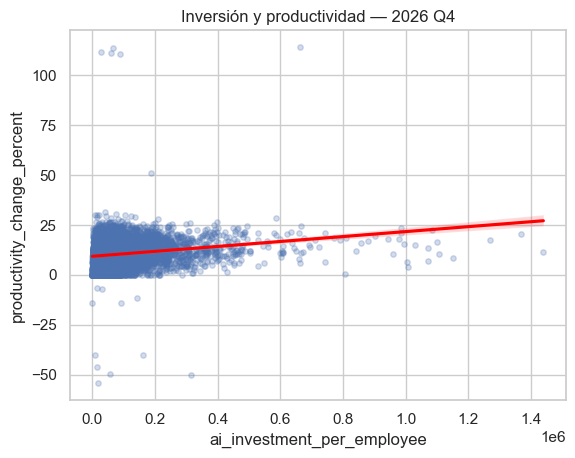

,ai_investment_per_employee,productivity_change_percent
ai_investment_per_employee,1.000000,0.189076
productivity_change_percent,0.189076,1.000000


In [32]:
panel = company.dropna(
    subset=[
        'company_id',
        'survey_year',
        'quarter',
        'ai_investment_per_employee',
        'productivity_change_percent'
    ]
).copy()

panel['quarter_num'] = (
    panel['quarter']
    .str.extract(r'(\d)')[0]
    .astype(int)
)

latest_year = panel['survey_year'].max()
latest_quarter = panel.loc[
    panel['survey_year'].eq(latest_year),
    'quarter_num'
].max()

latest = panel[
    panel['survey_year'].eq(latest_year)
    & panel['quarter_num'].eq(latest_quarter)
    & panel['ai_investment_per_employee'].ge(0)
]

sns.regplot(
    data=latest,
    x='ai_investment_per_employee',
    y='productivity_change_percent',
    scatter_kws={'alpha': 0.25, 's': 15},
    line_kws={'color': 'red'}
)

plt.title(f'Inversión y productividad — {int(latest_year)} Q{latest_quarter}')
plt.show()

latest[
    ['ai_investment_per_employee', 'productivity_change_percent']
].corr()

Tanto en el análisis global como en los datos disponibles del último trimestre del 2025, la correlación entre las variables es muy baja ($r=0.19$) y el gráfico de dispersión da cuenta de que no hay una relación muy clara entre las variables: incluso niveles bajos de inversión están asociados a cambios grandes en la productividad, mientras que niveles altos de inversión no parecen motorizar grandes cambios. 

A continuación, analizamos el promedio de inversión por empleado por compañía a lo largo de todo el período, y lo comparamos con el cambio de productividad promedio por compañía. Esto nos permite observar si existe alguna relación a nivel agregado, en lugar de a nivel individual. 

,avg_ai_investment,avg_productivity_change
avg_ai_investment,1.000000,0.238365
avg_productivity_change,0.238365,1.000000


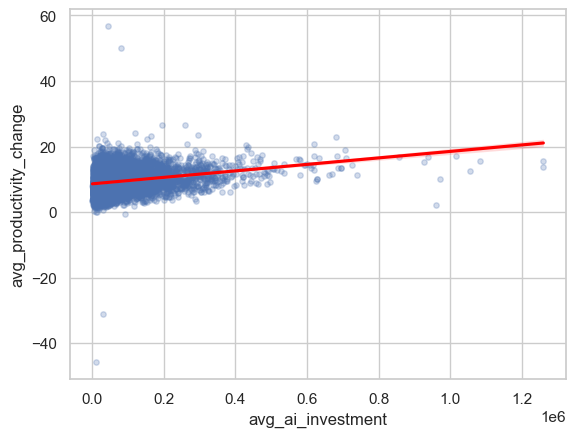

In [33]:
company_level = (
    panel[panel['ai_investment_per_employee'].ge(0)]
    .groupby('company_id', as_index=False)
    .agg(
        avg_ai_investment=('ai_investment_per_employee', 'mean'),
        avg_productivity_change=('productivity_change_percent', 'mean')
    )
)

sns.regplot(
    data=company_level,
    x='avg_ai_investment',
    y='avg_productivity_change',
    scatter_kws={'alpha': 0.25, 's': 15},
    line_kws={'color': 'red'}
)

company_level[
    ['avg_ai_investment', 'avg_productivity_change']
].corr()

Al agregar los datos temporales por compañía, la correlación entre las variables aumenta ligeramente ($r=0.2383$), como se observa en el gráfico de dispersión y en la matriz de correlación. Esto sugiere una relación más clara entre inversión y productividad cuando se considera la inversión promedio por empleado a lo largo del tiempo, en lugar de observar solo un trimestre aislado.

### Diferencias entre regiones y vínculo país-madurez digital

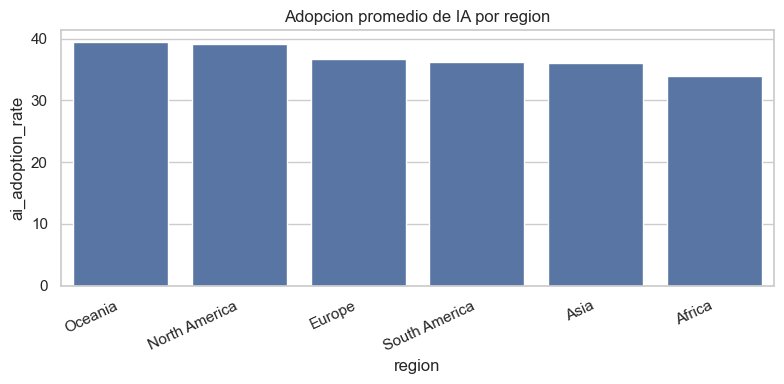

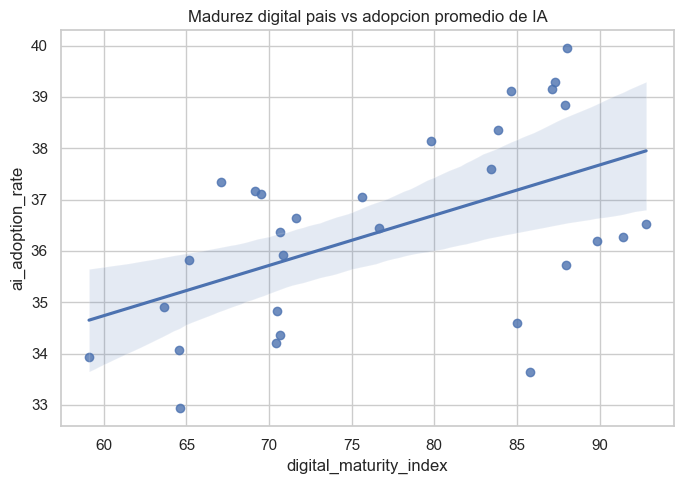

,digital_maturity_index,ai_adoption_rate
digital_maturity_index,1.000,0.521
ai_adoption_rate,0.521,1.000


In [34]:
region_mean = company.groupby('region', as_index=False)['ai_adoption_rate'].mean().sort_values('ai_adoption_rate', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=region_mean, x='region', y='ai_adoption_rate')
plt.title('Adopcion promedio de IA por region')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

country_adoption = company.groupby('country', as_index=False)['ai_adoption_rate'].mean()
country_merged = country_adoption.merge(country[['country', 'digital_maturity_index']], on='country', how='left')

plt.figure(figsize=(7, 5))
sns.regplot(data=country_merged, x='digital_maturity_index', y='ai_adoption_rate')
plt.title('Madurez digital pais vs adopcion promedio de IA')
plt.tight_layout()
plt.show()

country_merged[['digital_maturity_index', 'ai_adoption_rate']].corr().round(3)

Los continentes con mayor tasa de adopción de IA son Oceanía y América del Norte, mientras que Asia y África muestran las tasas de adopción más bajas. Esto es algo que podría esperarse, dado que los países de Oceanía y América del Norte suelen tener economías más desarrolladas y una mayor inversión en tecnología e innovación. Por otro lado, Asia y África presentan desafíos estructurales y económicos que podrían limitar la adopción de IA.

El gráfico de dispersión entre el índice de madurez digital y la adopción promedio de IA por país muestra una relación positiva, aunque no perfecta. Esto sugiere que los países con mayor madurez digital tienden a tener una mayor adopción de IA, lo que podría reflejar una mayor capacidad para implementar y aprovechar tecnologías avanzadas. Sin embargo, también hay excepciones, lo que indica que otros factores, como políticas gubernamentales, infraestructura tecnológica y cultura empresarial, pueden influir en la adopción de IA más allá de la madurez digital.